In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
from pathlib import Path
import os

In [3]:
def blur(img):

    img_float = np.array(img, dtype=np.float32)

    dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols), np.float32)
    cv2.circle(mask, (ccol, crow), 40, 1, -1)
    mask = cv2.GaussianBlur(mask, (31, 31),0)

    mask = cv2.merge([mask, mask])
    fshift = dft_shift * mask

    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return img_back

In [4]:
def high_pass(img):

    img_float = np.array(img, dtype=np.float32)

    dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.ones((rows, cols), np.float32)
    cv2.circle(mask, (ccol, crow), 40, 0, -1)
    mask = cv2.GaussianBlur(mask, (31, 31),0)

    mask = cv2.merge([mask, mask])
    fshift = dft_shift * mask

    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return img_back

In [5]:

def process_image1(img):
    blurred_img = blur(img)

    edges = cv2.Canny(blurred_img, 100, 200)

    kernel = np.ones((3,3), np.uint8)
    fechamento = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=7)


    return fechamento

In [ ]:
def process_image2(img):
    blurred_img = high_pass(img)
    # plt.imshow(blurred_img, cmap='gray')
    binary_img = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    plt.imshow(binary_img, cmap='gray')
    kernel = np.ones((3,3), np.uint8)
    fechamento = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=4)

    return fechamento

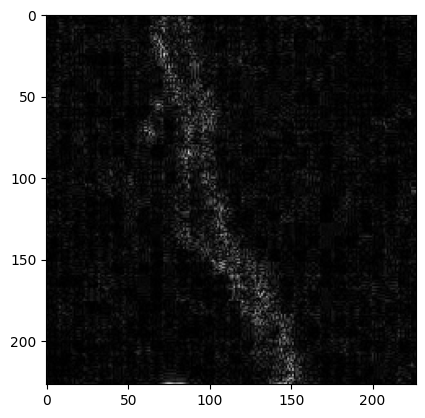

In [26]:
img = cv2.imread("Pos/00001.jpg", cv2.IMREAD_GRAYSCALE)

img = process_image2(img)
# plt.imshow(img, cmap='gray')

In [19]:
pasta_negativa = "./Neg"         # onde estão os JPGs
pasta_positiva   = "./Pos"         # onde estão os JPGs

pasta_s_negativa = "./Negativa2"         # onde salvar os processados
pasta_s_positiva = "./Positiva2"         # onde salvar os processados

# 1. Criar pasta de saída se não existir
os.makedirs(pasta_s_negativa, exist_ok=True)
os.makedirs(pasta_s_positiva, exist_ok=True)

# 2. Listar todos os JPGs
paths1 = glob.glob(os.path.join(pasta_positiva, "*.jpg"))

for p in paths1:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Falha ao ler:", p)
        continue
    processada = process_image2(img)
    # 3. Montar nome de arquivo na pasta de saída
    nome = os.path.basename(p)                 # ex: "foto1.jpg"
    caminho_out = os.path.join(pasta_s_positiva, nome)

    # 4. Salvar a imagem (pode ser processada antes, se quiser)
    ok = cv2.imwrite(caminho_out, processada)
    if not ok:
        print("Falha ao salvar:", caminho_out)


paths2 = glob.glob(os.path.join(pasta_negativa, "*.jpg"))

for p in paths2:
    
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Falha ao ler:", p)
        continue
    processada = process_image2(img)
    # 3. Montar nome de arquivo na pasta de saída
    nome = os.path.basename(p)                 # ex: "foto1.jpg"
    caminho_out = os.path.join(pasta_s_negativa, nome)

    # 4. Salvar a imagem (pode ser processada antes, se quiser)
    ok = cv2.imwrite(caminho_out, processada)
    if not ok:
        print("Falha ao salvar:", caminho_out)